# Exploratory Data Analysis (EDA)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_theme(context='talk', style='whitegrid', palette='colorblind')

pd.options.display.float_format = '{:.2f}'.format
np.random.seed(210)


## Data Loading
In this part, I will be giving the necessary datasets.

In [2]:
base_games = pd.read_csv('base_games.csv')
demos = pd.read_csv('demos.csv')
scores = pd.read_csv('scores.csv')
sales = pd.read_csv('vgsales.csv')

print(base_games.shape, demos.shape, scores.shape, sales.shape)
base_games.head()

sales.info()
sales.head()

/var/folders/7j/81wr6y7d5_56szf85g5pfkm00000gn/T/ipykernel_21202/1128737883.py:1: DtypeWarning: Columns (0,5,10) have mixed types. Specify dtype option on import or set low_memory=False.
  base_games = pd.read_csv('base_games.csv')


(116761, 12) (15463, 3) (142417, 6) (16598, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.00,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.00,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.00,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.00,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Data Cleaning
In this part, I will get rid of redundant characters to have clean titles for each dataframe. By doing so, I will be able to match the the game names to the corresponding data. During the function part, I used AI to understand the syntax and algorithm.

In [14]:
def clean_title(t):
    if pd.isna(t): return np.nan
    text = str(t).lower()
    text = re.sub(r'\(.*?\)', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[-–:|]', ' ', text)
    text = re.sub(r'[^0-9a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

#cleaning the titles in every dataframe
base_games['base_name'] = base_games['name'].apply(clean_title)
scores['base_name'] = scores['name'].apply(clean_title)
sales['base_name'] = sales['Name'].apply(clean_title)

sales[['Name','Platform','Global_Sales','base_name']].head()

#converting each dataframe's selected columns to numeric values 
base_games['metacritic'] = pd.to_numeric(base_games['metacritic'], errors='coerce')
scores['metascore'] = pd.to_numeric(scores['metascore'], errors='coerce')
scores['userscore'] = pd.to_numeric(scores['userscore'], errors='coerce')



## Data Merging
I also used AI in this part to show me in which order I was supposed to merge the attributes and then the datasets.

In [ ]:
#merging each demo row with its corresponding full game data
games_with_demos = demos.merge(
    base_games,
    left_on='full_game_appid', 
    right_on='steam_appid',
    how='left',
    suffixes=('_demo','_full')
)

#if a match is found join the columns together
games_with_demos['base_name'] = games_with_demos['name_full'].apply(clean_title)
games_with_demos.head()


,demo_appid,full_game_appid,name_demo,steam_appid,name_full,windows,mac,linux,metacritic,steam_achievements,steam_trading_cards,workshop_support,genres,achievements_total,release_date,base_name,release_date_parsed,has_demo
0,2573370,2214650,Rolando Deluxe Demo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1,2573460,1439980,Outrunner: Neon Nights Demo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
2,2572840,2412240,Bubble Ghost Remake Demo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
3,2572240,2448830,Time Handlers Demo,2448830,Time Handlers,True,True,True,NaN,True,False,False,"Adventure, Indie",32,"Jan 11, 2024",time handlers,2024-01-11,True
4,2570800,2379590,Hope's Final Defense Demo,2379590,Hope's Final Defense,True,True,True,NaN,True,True,True,"Action, RPG",NaN,To be announced,hopes final defense,NaT,True


In the cell belove, rows of score where the platform is "PC" is extracted. Thus, it gives **True** if the platform is **PC**, **False** otherwise.

In [16]:
scores_pc = scores[scores['platform']=='PC'].copy()

demo_full_scores = games_with_demos.merge(
    scores_pc[['base_name','metascore','userscore']],
    on='base_name',
    how='left'
)

demo_full_scores.head()


,demo_appid,full_game_appid,name_demo,steam_appid,name_full,windows,mac,linux,metacritic,steam_achievements,steam_trading_cards,workshop_support,genres,achievements_total,release_date,base_name,release_date_parsed,has_demo,metascore,userscore
0,2573370,2214650,Rolando Deluxe Demo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,2573460,1439980,Outrunner: Neon Nights Demo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,2572840,2412240,Bubble Ghost Remake Demo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,2572240,2448830,Time Handlers Demo,2448830,Time Handlers,True,True,True,NaN,True,False,False,"Adventure, Indie",32,"Jan 11, 2024",time handlers,2024-01-11,True,NaN,NaN
4,2570800,2379590,Hope's Final Defense Demo,2379590,Hope's Final Defense,True,True,True,NaN,True,True,True,"Action, RPG",NaN,To be announced,hopes final defense,NaT,True,NaN,NaN


In the cell below, we merge score and sales data. However, only the **cleaned full game name** and **global sales** will be merged into a dataframe. Then, rows where **base name** from **demo_full_scores** equals **base name** from **sales** is matched.

In [17]:
demo_full_sales = demo_full_scores.merge(
    sales[['base_name','Global_Sales']],
    on='base_name',
    how='left'
)

demo_full_sales[['name_full','metacritic','metascore','Global_Sales']].head()


,name_full,metacritic,metascore,Global_Sales
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,Time Handlers,NaN,NaN,NaN
4,Hope's Final Defense,NaN,NaN,NaN


In [18]:
# show how many games gave demos
base_games['has_demo'] = base_games['steam_appid'].isin(demos['full_game_appid'])
base_games['has_demo'].value_counts()


has_demo
False    108127
True       8634
Name: count, dtype: int64

In [19]:
# compare metacritic scores for games with and without demos
score_stats = base_games.groupby('has_demo')['metacritic'].agg(['count','mean','median'])
score_stats.index = score_stats.index.map({True:'Has demo', False:'No demo'})
score_stats


,count,mean,median
has_demo,,,
No demo,3005,73.90,75.00
Has demo,246,73.97,75.50


## Boxplot for Comparing the sales of Demos and Non-demo Game

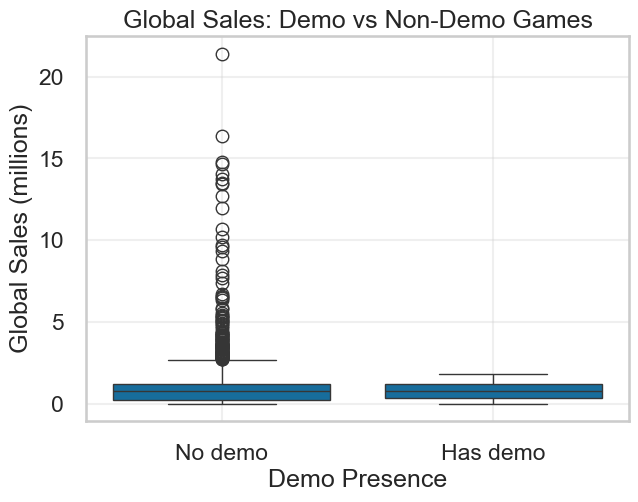

In [ ]:

# merge steam game info with sales info
games_all_sales = base_games.merge(
    sales[['base_name', 'Platform', 'Global_Sales']],
    on='base_name',
    how='left'
)

# Make a clean dataframe for the boxplot by getting global_sales for y axis and has_demo for x axis, then removw any rows with missing data
plot_df_sales = games_all_sales[['Global_Sales', 'has_demo']].dropna().copy()
plot_df_sales['demo_label'] = plot_df_sales['has_demo'].map({True: 'Has demo', False: 'No demo'})

plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_df_sales, x='demo_label', y='Global_Sales')
plt.xlabel("Demo Presence")
plt.ylabel("Global Sales (millions)")
plt.title("Global Sales: Demo vs Non-Demo Games")
plt.grid(alpha=0.3)
plt.show()


## Histogram of Global Sales Across All Games

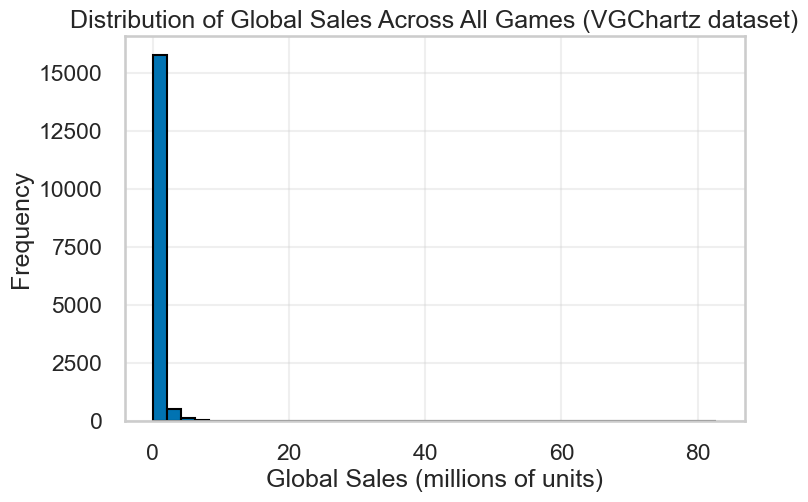

In [10]:
sales_clean = sales['Global_Sales'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(sales_clean, bins=40, edgecolor='black')
plt.xlabel("Global Sales (millions of units)")
plt.ylabel("Frequency")
plt.title("Distribution of Global Sales Across All Games (VGChartz dataset)")
plt.grid(alpha=0.3)
plt.show()


## Histogram of Review Scores for all Games

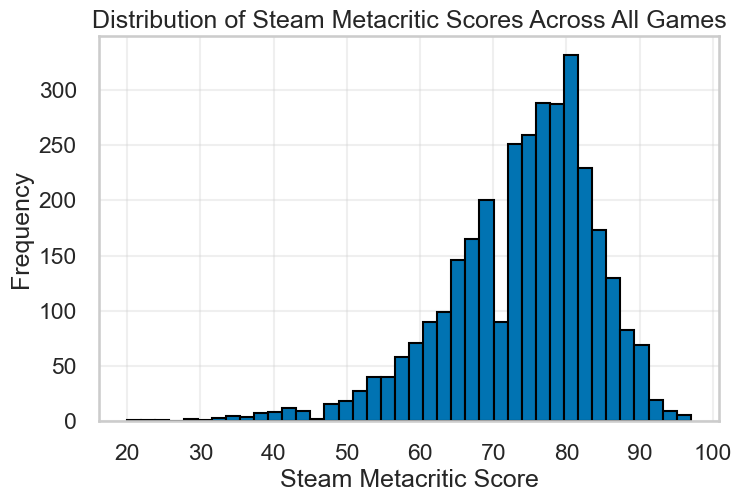

In [ ]:
scores_clean = base_games['metacritic'].dropna()

#create a new plot
plt.figure(figsize=(8, 5))
plt.hist(scores_clean, bins=40, edgecolor='black')
plt.xlabel("Steam Metacritic Score")
plt.ylabel("Frequency")
plt.title("Distribution of Steam Metacritic Scores Across All Games")
plt.grid(alpha=0.3)
plt.show()


## Boxplot for Comparing Scores of Demo and Non-demo Games

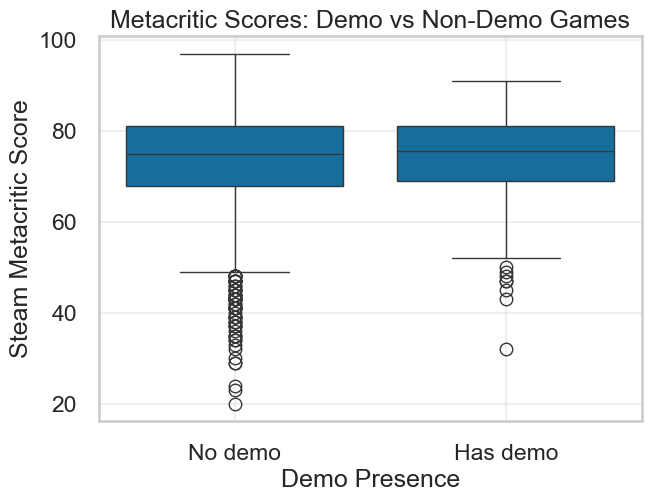

In [ ]:
plot_df_scores = base_games[['metacritic', 'has_demo']].dropna().copy()
plot_df_scores['demo_label'] = plot_df_scores['has_demo'].map({True: 'Has demo', False: 'No demo'}) #turn booleans into understandable labels

#create boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_df_scores, x='demo_label', y='metacritic')
plt.xlabel("Demo Presence")
plt.ylabel("Steam Metacritic Score")
plt.title("Metacritic Scores: Demo vs Non-Demo Games")
plt.grid(alpha=0.3)
plt.show()


## Scatter Plot to Observe if Demo Popularity is Directly Proportional with Sales of the Game

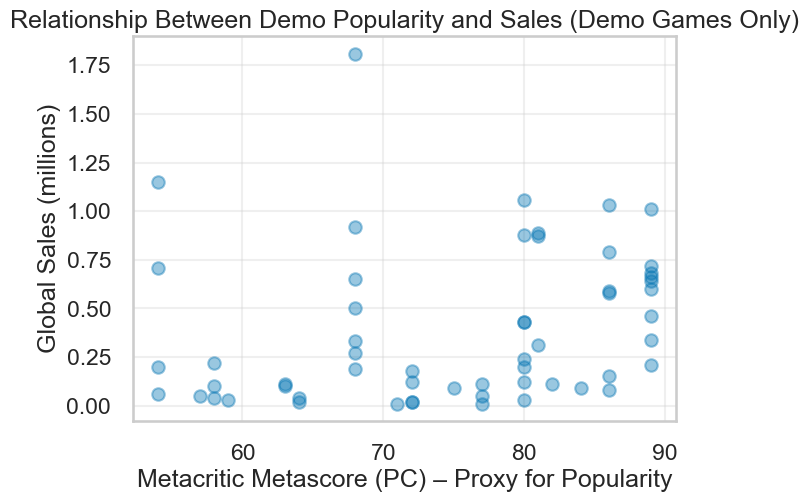

In [ ]:
scatter_df = demo_full_sales[['metascore', 'Global_Sales']].dropna().copy()

#create scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(scatter_df['metascore'], scatter_df['Global_Sales'], alpha=0.4)
plt.xlabel("Metacritic Metascore (PC) – Proxy for Popularity")
plt.ylabel("Global Sales (millions)")
plt.title("Relationship Between Demo Popularity and Sales (Demo Games Only)")
plt.grid(alpha=0.3)
plt.show()
